# Fraud Detection — Exploratory Data Analysis
### IEEE-CIS Fraud Detection Dataset
This notebook explores the transaction and identity data, analyzes class imbalance, and uncovers patterns that distinguish fraudulent from legitimate transactions.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look clean
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 50)


In [3]:
# Loading the datasets
transaction = pd.read_csv('../data/train_transaction.csv')
identity = pd.read_csv('../data/train_identity.csv')

print(f"Transactions: {transaction.shape[0]:,} rows, {transaction.shape[1]} columns")
print(f"Identity:     {identity.shape[0]:,} rows, {identity.shape[1]} columns")

Transactions: 590,540 rows, 394 columns
Identity:     144,233 rows, 41 columns


In [4]:
transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
fraud_counts = transaction['isFraud'].value_counts()
fraud_rate = transaction['isFraud'].mean() * 100

print(f"Legitimate transactions: {fraud_counts[0]:,}")
print(f"Fraudulent transactions: {fraud_counts[1]:,}")
print(f"Fraud rate: {fraud_rate:.2f}%")

Legitimate transactions: 569,877
Fraudulent transactions: 20,663
Fraud rate: 3.50%


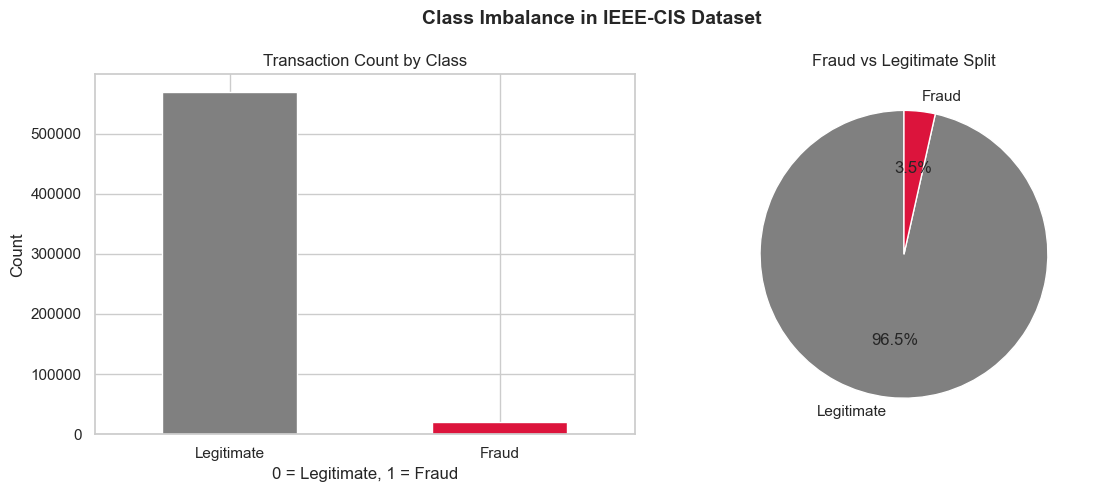

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
fraud_counts.plot(kind='bar', ax=axes[0], color=['gray', 'crimson'], edgecolor='white')
axes[0].set_title('Transaction Count by Class')
axes[0].set_xlabel('0 = Legitimate, 1 = Fraud')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

# Pie chart
axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.1f%%',
            colors=['gray', 'crimson'], startangle=90)
axes[1].set_title('Fraud vs Legitimate Split')

plt.suptitle('Class Imbalance in IEEE-CIS Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

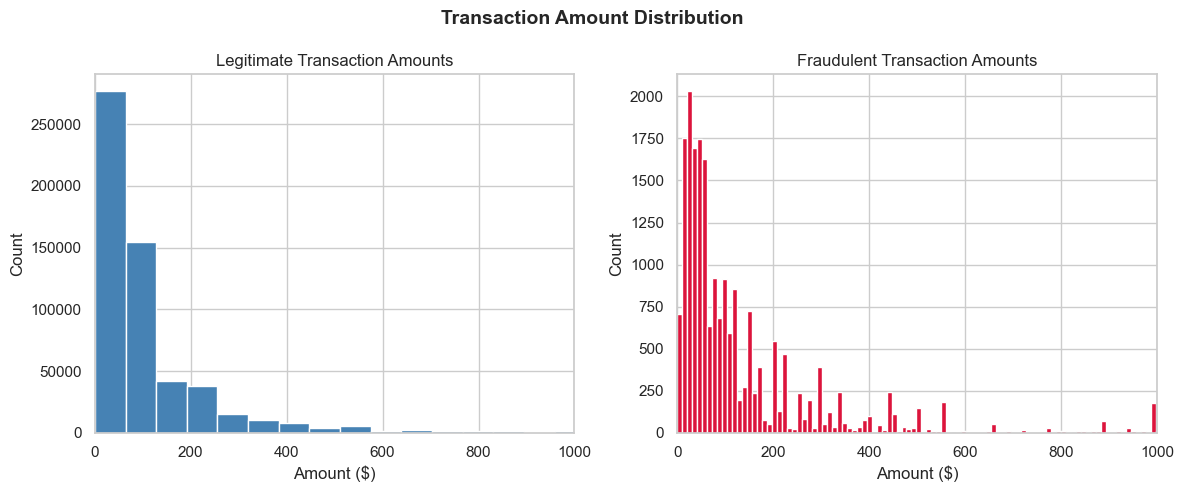

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Legit transactions
axes[0].hist(transaction[transaction['isFraud'] == 0]['TransactionAmt'], 
             bins=500, color='steelblue', edgecolor='white')
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1000)

# Fraud transactions
axes[1].hist(transaction[transaction['isFraud'] == 1]['TransactionAmt'], 
             bins=500, color='crimson', edgecolor='white')
axes[1].set_title('Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 1000)

plt.suptitle('Transaction Amount Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
product_fraud = transaction.groupby('ProductCD')['isFraud'].agg(['sum', 'count', 'mean'])
product_fraud.columns = ['fraud_count', 'total_count', 'fraud_rate']
product_fraud['fraud_rate'] = product_fraud['fraud_rate'] * 100
product_fraud = product_fraud.sort_values('fraud_rate', ascending=False)

print(product_fraud)

           fraud_count  total_count  fraud_rate
ProductCD                                      
C                 8008        68519   11.687269
S                  686        11628    5.899553
H                 1574        33024    4.766231
R                 1426        37699    3.782594
W                 8969       439670    2.039939


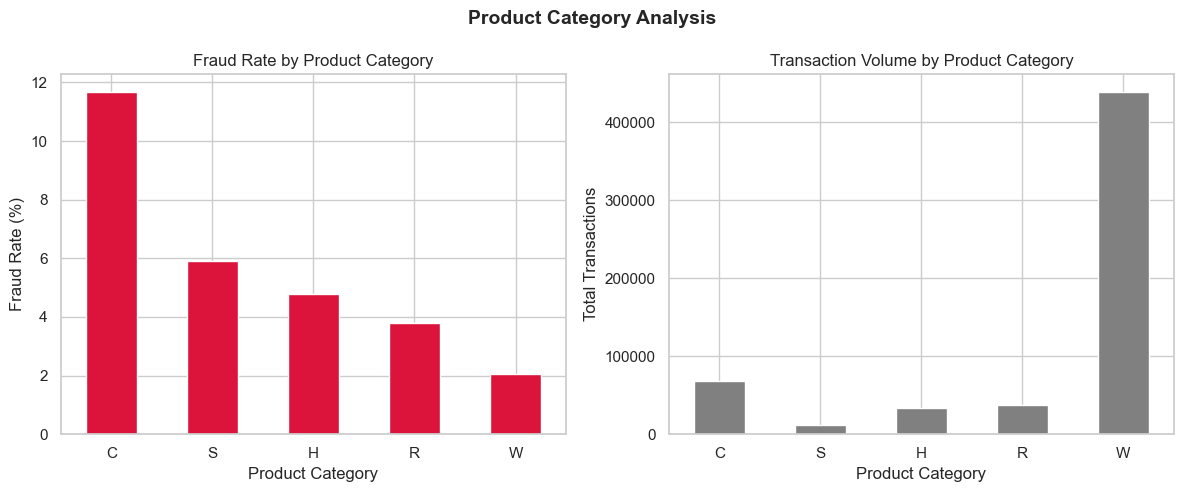

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fraud rate by product
product_fraud['fraud_rate'].plot(kind='bar', ax=axes[0], color='crimson', edgecolor='white')
axes[0].set_title('Fraud Rate by Product Category')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticklabels(product_fraud.index, rotation=0)

# Total volume by product
product_fraud['total_count'].plot(kind='bar', ax=axes[1], color='gray', edgecolor='white')
axes[1].set_title('Transaction Volume by Product Category')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Total Transactions')
axes[1].set_xticklabels(product_fraud.index, rotation=0)

plt.suptitle('Product Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
card_fraud = transaction.groupby('card4')['isFraud'].agg(['sum', 'count', 'mean'])
card_fraud.columns = ['fraud_count', 'total_count', 'fraud_rate']
card_fraud['fraud_rate'] = card_fraud['fraud_rate'] * 100
card_fraud = card_fraud.sort_values('fraud_rate', ascending=False)

print(card_fraud)

                  fraud_count  total_count  fraud_rate
card4                                                 
discover                  514         6651    7.728161
visa                    13373       384767    3.475610
mastercard               6496       189217    3.433095
american express          239         8328    2.869837


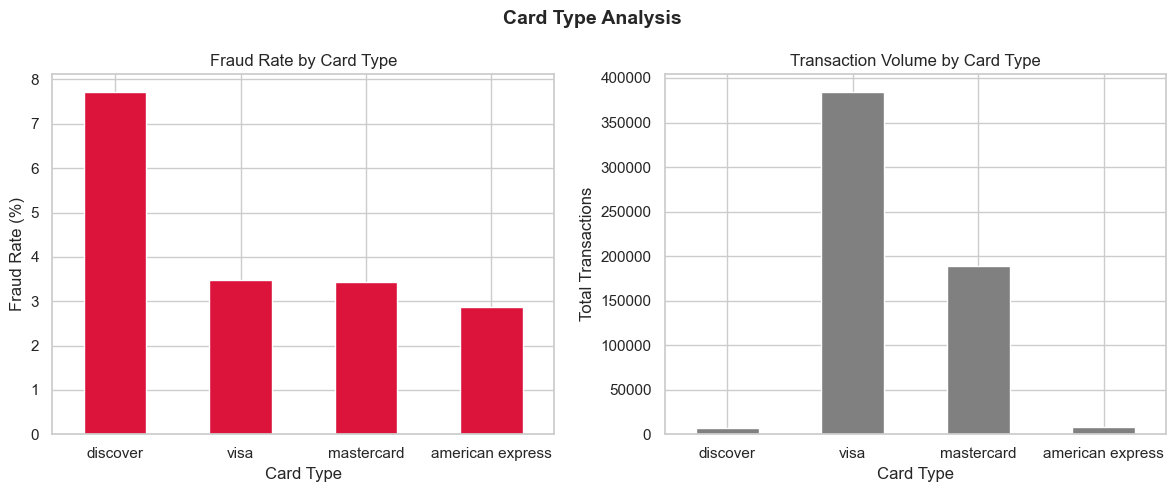

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

card_fraud['fraud_rate'].plot(kind='bar', ax=axes[0], color='crimson', edgecolor='white')
axes[0].set_title('Fraud Rate by Card Type')
axes[0].set_xlabel('Card Type')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticklabels(card_fraud.index, rotation=0)

card_fraud['total_count'].plot(kind='bar', ax=axes[1], color='gray', edgecolor='white')
axes[1].set_title('Transaction Volume by Card Type')
axes[1].set_xlabel('Card Type')
axes[1].set_ylabel('Total Transactions')
axes[1].set_xticklabels(card_fraud.index, rotation=0)

plt.suptitle('Card Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
missing = transaction.isnull().sum()
missing_pct = (missing / len(transaction) * 100).round(2)

missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)} out of {transaction.shape[1]}")
print(missing_df.head(20))

Columns with missing values: 374 out of 394
       missing_count  missing_pct
dist2         552913        93.63
D7            551623        93.41
D13           528588        89.51
D14           528353        89.47
D12           525823        89.04
D6            517353        87.61
D9            515614        87.31
D8            515614        87.31
V153          508595        86.12
V160          508589        86.12
V159          508589        86.12
V158          508595        86.12
V157          508595        86.12
V156          508595        86.12
V155          508595        86.12
V154          508595        86.12
V152          508589        86.12
V162          508595        86.12
V151          508589        86.12
V150          508589        86.12


## FINDINGS 
- Severe class imbalance: 590,540 transactions, only 3.5% fraud 
- Accuracy is a useless metric here because a model that predicts "never fraud" gets 96.5% accuracy but catches nothing
- Fraud skews toward lower transaction amounts
- Product C has highest fraud rate
- Visa has highest volume but Discover card has highest fraud rate
- 374 out of 394 columns have missing data